# Peetre decomposition with `psiop`

This notebook rewrites the original Peetre experiments with more explanation and a stronger focus on `PseudoDifferentialOperator.apply_peetre`.

The goals are:

1. Show how a symbol is split into local, separable, and joint parts in 1D and 2D.
2. Verify that `local + separable + joint` reconstructs the original symbol.
3. Compare `apply_peetre` with the direct `apply` method.
4. Distinguish exact Peetre application (`apply_joint=True`) from fast approximate Peetre application (`apply_joint=False`).
5. Demonstrate reuse of a decomposition for several inputs and for different boundary conditions.


## Peetre-style splitting

For a symbol `p(x, xi)`, the decomposition used here is:

```
p(x, xi) = p_local(x, xi) + p_separable(x, xi) + p_joint(x, xi)
```

where:

- `p_local` is polynomial in the frequency variables. It corresponds to a differential operator with variable coefficients.
- `p_separable` is a sum of terms `a(x) q(xi)`. It corresponds to pointwise multiplication by `a(x)` after applying the Fourier multiplier `q(D)`.
- `p_joint` contains genuinely coupled space-frequency terms. It is the expensive residual.

`apply_peetre` applies these three pieces separately. If `apply_joint=True`, the joint residual is still applied directly. If `apply_joint=False`, the joint residual is dropped, giving a local-plus-separable approximation.


In [1]:
%reload_ext autoreload
%autoreload 2

import warnings
import time
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# If your environment requires solver_qwen for shared constants or helpers,
# uncomment the following line.
# from solver_qwen import *

# Main package under study.
from psiop_qwen import PseudoDifferentialOperator


In [2]:
def relative_error(a, b):
    # Relative L2 error with a small safeguard against division by zero.
    return np.linalg.norm(a - b) / (np.linalg.norm(b) + 1e-16)


def make_1d_periodic_grid(N=256, L=2*np.pi):
    # Periodic physical grid and matching FFT frequencies.
    x = np.linspace(-L/2, L/2, N, endpoint=False)
    dx = x[1] - x[0]
    kx = 2*np.pi*np.fft.fftfreq(N, d=dx)
    return x, kx


def make_2d_periodic_grid(Nx=32, Ny=32, Lx=2*np.pi, Ly=2*np.pi):
    # Periodic 2D physical grids and matching FFT frequencies.
    x = np.linspace(-Lx/2, Lx/2, Nx, endpoint=False)
    y = np.linspace(-Ly/2, Ly/2, Ny, endpoint=False)

    dx = x[1] - x[0]
    dy = y[1] - y[0]

    kx = 2*np.pi*np.fft.fftfreq(Nx, d=dx)
    ky = 2*np.pi*np.fft.fftfreq(Ny, d=dy)

    X, Y = np.meshgrid(x, y, indexing='ij')

    return x, y, kx, ky, X, Y


## 1D symbolic Peetre decomposition

We first build a 1D symbol containing:

- a local polynomial part: `(1 + x**2) * xi**2 + x * xi`
- a genuinely joint oscillatory part: `sin(x * xi)`
- a non-polynomial mixed part: `exp(-(x - xi)**2)`

The Taylor refinement expands joint terms in the spatial variable around `x0 = 0`. The remaining unexpanded part is kept in the joint residual.


In [3]:
x, xi = sp.symbols('x xi', real=True)

p = (
    (1 + x**2) * xi**2
    + x * xi
    + sp.sin(x * xi)
    + sp.exp(-(x - xi)**2)
)

op = PseudoDifferentialOperator(
    expr=p,
    vars_x=[x],
    mode='symbol',
)

# Print the decomposition obtained after a spatial Taylor refinement.
op.print_peetre_decomposition(
    taylor_order=4,
    taylor_x0=[0],
    asymptotic_order=None,
    refinement_sequence=('taylor',),
)

# Retrieve the decomposition dictionary for further use.
deco = op.peetre_decomposition(
    taylor_order=4,
    taylor_x0=[0],
    asymptotic_order=None,
    refinement_sequence=('taylor',),
)

print('Decomposition keys:')
print(sorted(deco.keys()))

# Symbolic reconstruction check.
reconstructed = (
    deco['local_symbol']
    + deco['separable_symbol']
    + deco['joint_symbol']
)

error = sp.expand(reconstructed - p)

print('Reconstruction error, ideally simplified to 0:')
print(sp.simplify(error))


--- 3 local term(s), represented as a(x)*q(xi) ---
  (x**2 + 1) * (xi**2)
  (2*x) * (xi)
  (-x**3/6) * (xi**3)
--- 5 separable non-local term(s) ---
  (x**4/2 - x**2 + 1) * (exp(-xi**2))
  (2*x*(1 - x**2)) * (xi*exp(-xi**2))
  (2*x**2*(1 - x**2)) * (xi**2*exp(-xi**2))
  (2*x**4/3) * (xi**4*exp(-xi**2))
  (4*x**3/3) * (xi**3*exp(-xi**2))
--- 1 irreducible joint term(s) ---
  -2*x**4*xi**4*exp(-xi**2)/3 + 2*x**4*xi**2*exp(-xi**2) - x**4*exp(-xi**2)/2 + x**3*xi**3/6 - 4*x**3*xi**3*exp(-xi**2)/3 + 2*x**3*xi*exp(-xi**2) - 2*x**2*xi**2*exp(-xi**2) + x**2*exp(-xi**2) - x*xi - 2*x*xi*exp(-xi**2) + sin(x*xi) - exp(-xi**2) + exp(-x**2)*exp(-xi**2)*exp(2*x*xi)
local_symbol = -x**3*xi**3/6 + x**2*xi**2 + 2*x*xi + xi**2
separable_symbol = 2*x**4*xi**4*exp(-xi**2)/3 - 2*x**4*xi**2*exp(-xi**2) + x**4*exp(-xi**2)/2 + 4*x**3*xi**3*exp(-xi**2)/3 - 2*x**3*xi*exp(-xi**2) + 2*x**2*xi**2*exp(-xi**2) - x**2*exp(-xi**2) + 2*x*xi*exp(-xi**2) + exp(-xi**2)
joint_symbol = -2*x**4*xi**4*exp(-xi**2)/3 + 2*x**4*xi*

## 1D numerical application with `apply_peetre`

We now compare three computations:

1. `op.apply(...)`: direct application of the full symbol.
2. `op.apply_peetre(..., apply_joint=True)`: exact Peetre application, including the joint residual.
3. `op.apply_peetre(..., apply_joint=False)`: approximate Peetre application, keeping only local and separable parts.

The exact Peetre application should be close to the direct application. The approximate one is usually faster but less accurate, especially away from the Taylor expansion point.


In [4]:
x, xi = sp.symbols('x xi', real=True)

p_apply = (
    (1 + x**2) * xi**2
    + x * xi
    + sp.sin(x * xi)
)

op_apply = PseudoDifferentialOperator(
    expr=p_apply,
    vars_x=[x],
    mode='symbol',
)

x_grid, kx = make_1d_periodic_grid(N=256, L=2*np.pi)
u = np.exp(-x_grid**2)

deco_apply = op_apply.peetre_decomposition(
    taylor_order=4,
    taylor_x0=[0],
    asymptotic_order=None,
    refinement_sequence=('taylor',),
)

# Reference: apply the complete symbol directly.
v_full = op_apply.apply(
    u,
    x_grid,
    kx,
    boundary_condition='periodic',
    freq_window=None,
    clamp=1e12,
)

# Exact Peetre application: local + separable + joint residual.
v_peetre_exact = op_apply.apply_peetre(
    u,
    x_grid,
    kx,
    boundary_condition='periodic',
    decomposition=deco_apply,
    apply_joint=True,
    freq_window=None,
    clamp=1e12,
)

# Approximate Peetre application: drop the joint residual.
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    v_peetre_approx = op_apply.apply_peetre(
        u,
        x_grid,
        kx,
        boundary_condition='periodic',
        decomposition=deco_apply,
        apply_joint=False,
        freq_window=None,
        clamp=1e12,
    )

print('Relative error exact Peetre vs full apply:')
print(relative_error(v_peetre_exact, v_full))

print('Relative error approximate Peetre vs full apply:')
print(relative_error(v_peetre_approx, v_full))

print('Relative error approximate vs exact Peetre:')
print(relative_error(v_peetre_approx, v_peetre_exact))


Relative error exact Peetre vs full apply:
7.731766423530058e-13
Relative error approximate Peetre vs full apply:
0.669081707261864
Relative error approximate vs exact Peetre:
0.6690817072623435


## Purely separable 1D symbol

A symbol of the form `a(x) q(xi)` should be detected as separable. In that case, `apply_peetre` is especially efficient because it applies the Fourier multiplier `q(D)` once and then multiplies by `a(x)`.


In [5]:
x, xi = sp.symbols('x xi', real=True)

p_sep = sp.exp(-x**2) * sp.sqrt(xi**2 + 1)

op_sep = PseudoDifferentialOperator(
    expr=p_sep,
    vars_x=[x],
    mode='symbol',
)

x_grid, kx = make_1d_periodic_grid(N=512, L=4*np.pi)
u_sep = np.exp(-x_grid**2) * np.cos(5*x_grid)

deco_sep = op_sep.peetre_decomposition()

op_sep.print_peetre_decomposition()

# Full application of the separable symbol.
v_full_sep = op_sep.apply(
    u_sep,
    x_grid,
    kx,
    boundary_condition='periodic',
    freq_window='gaussian',
    clamp=1e6,
)

# Peetre application. Since there is no joint part, apply_joint=False is equivalent.
v_peetre_sep = op_sep.apply_peetre(
    u_sep,
    x_grid,
    kx,
    boundary_condition='periodic',
    decomposition=deco_sep,
    apply_joint=True,
    freq_window='gaussian',
    clamp=1e6,
)

print('Relative error separable Peetre vs full apply:')
print(relative_error(v_peetre_sep, v_full_sep))


--- 0 local term(s), polynomial in (xi,) ---
--- 1 separable non-local term(s) ---
  (exp(-x**2)) * (sqrt(xi**2 + 1))
--- 0 irreducible joint term(s) ---
local_symbol = 0
separable_symbol = sqrt(xi**2 + 1)*exp(-x**2)
joint_symbol = 0
Relative error separable Peetre vs full apply:
1.0874988783651063e-05


## Reusing a Peetre decomposition

If the operator is fixed and many input fields must be processed, it is useful to compute the decomposition once and pass it through the `decomposition` argument.

This avoids repeated symbolic work and makes `apply_peetre` suitable for time stepping or parameter studies.


In [6]:
# Reuse the decomposition deco_apply computed earlier.

u1 = np.exp(-x_grid**2)
u2 = np.exp(-10*x_grid**2) * np.cos(8*x_grid)
u3 = 1 / np.cosh(x_grid)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    v1 = op_apply.apply_peetre(
        u1,
        x_grid,
        kx,
        boundary_condition='periodic',
        decomposition=deco_apply,
        apply_joint=False,
    )

    v2 = op_apply.apply_peetre(
        u2,
        x_grid,
        kx,
        boundary_condition='periodic',
        decomposition=deco_apply,
        apply_joint=False,
    )

    v3 = op_apply.apply_peetre(
        u3,
        x_grid,
        kx,
        boundary_condition='periodic',
        decomposition=deco_apply,
        apply_joint=False,
    )

print('Norm v1:', np.linalg.norm(v1))
print('Norm v2:', np.linalg.norm(v2))
print('Norm v3:', np.linalg.norm(v3))


Norm v1: 27.600367469049125
Norm v2: 267.37742847368065
Norm v3: 1571.4506129274707


## Taylor-order convergence of the approximate Peetre application

When `apply_joint=False`, the accuracy depends strongly on the Taylor order and on the distance between the support of `u` and the expansion point `taylor_x0`.

The following loop computes approximate Peetre applications for several Taylor orders and compares them against the full direct application.


Taylor order 0: relative error = 2.707415e-01
Taylor order 1: relative error = 1.560657e-01
Taylor order 2: relative error = 1.560657e-01
Taylor order 3: relative error = 7.289728e-01
Taylor order 4: relative error = 7.289728e-01
Taylor order 5: relative error = 3.734887e+03


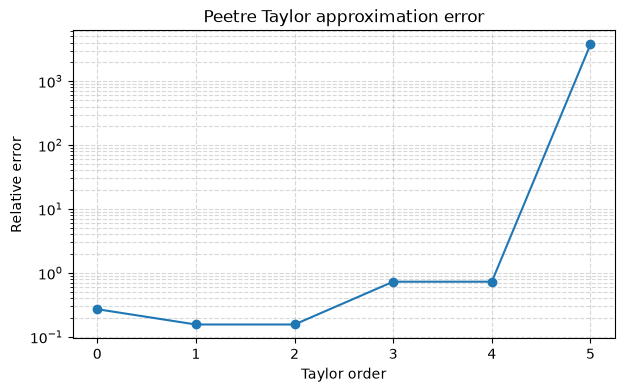

In [7]:
x, xi = sp.symbols('x xi', real=True)

p_conv = (1 + x**2) * xi**2 + sp.sin(x * xi)

op_conv = PseudoDifferentialOperator(
    expr=p_conv,
    vars_x=[x],
    mode='symbol',
)

x_grid, kx = make_1d_periodic_grid(N=256, L=2*np.pi)
u_conv = np.exp(-x_grid**2)

# Reference full application.
v_ref_conv = op_conv.apply(
    u_conv,
    x_grid,
    kx,
    boundary_condition='periodic',
    freq_window=None,
    clamp=1e12,
)

errors_conv = []
orders = [0, 1, 2, 3, 4, 5]

for order in orders:
    deco_conv = op_conv.peetre_decomposition(
        taylor_order=order,
        taylor_x0=[0],
        asymptotic_order=None,
        refinement_sequence=('taylor',),
    )

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')

        v_conv_approx = op_conv.apply_peetre(
            u_conv,
            x_grid,
            kx,
            boundary_condition='periodic',
            decomposition=deco_conv,
            apply_joint=False,
            freq_window=None,
            clamp=1e12,
        )

    err = relative_error(v_conv_approx, v_ref_conv)
    errors_conv.append(err)
    print(f'Taylor order {order}: relative error = {err:.6e}')

plt.figure(figsize=(7, 4))
plt.semilogy(orders, errors_conv, 'o-')
plt.xlabel('Taylor order')
plt.ylabel('Relative error')
plt.title('Peetre Taylor approximation error')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()


## Optional: non-periodic Dirichlet application

`apply_peetre` also supports non-periodic boundary conditions through the underlying non-periodic Kohn-Nirenberg backend.

Here we use a simple non-periodic grid and an arbitrary frequency grid. In this setting, the frequency grid is not produced by an FFT but is used directly in the quadrature/matrix representation.


In [8]:
x, xi = sp.symbols('x xi', real=True)

p_dir = (
    (1 + x**2) * xi**2
    + x * xi
    + sp.sin(x * xi)
)

op_dir = PseudoDifferentialOperator(
    expr=p_dir,
    vars_x=[x],
    mode='symbol',
)

N_dir = 256
x_dir = np.linspace(-5.0, 5.0, N_dir, endpoint=False)
xi_dir = np.linspace(-30.0, 30.0, N_dir)
u_dir = np.exp(-x_dir**2)

deco_dir = op_dir.peetre_decomposition(
    taylor_order=5,
    taylor_x0=[0],
    asymptotic_order=None,
    refinement_sequence=('taylor',),
)

# Full non-periodic application.
v_dir_full = op_dir.apply(
    u_dir,
    x_dir,
    xi_dir,
    boundary_condition='dirichlet',
    freq_window='gaussian',
    clamp=1e6,
)

# Exact Peetre application, including the joint residual.
v_dir_exact = op_dir.apply_peetre(
    u_dir,
    x_dir,
    xi_dir,
    boundary_condition='dirichlet',
    decomposition=deco_dir,
    apply_joint=True,
    freq_window='gaussian',
    clamp=1e6,
)

# Approximate Peetre application, dropping the joint residual.
with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    v_dir_approx = op_dir.apply_peetre(
        u_dir,
        x_dir,
        xi_dir,
        boundary_condition='dirichlet',
        decomposition=deco_dir,
        apply_joint=False,
        freq_window='gaussian',
        clamp=1e6,
    )

print('Dirichlet relative error exact Peetre vs full apply:')
print(relative_error(v_dir_exact, v_dir_full))

print('Dirichlet relative error approximate Peetre vs full apply:')
print(relative_error(v_dir_approx, v_dir_full))


Dirichlet relative error exact Peetre vs full apply:
1.8517764240328437e-05
Dirichlet relative error approximate Peetre vs full apply:
0.4477221307561774


/home/philippe/psipy/src/psiop_qwen.py:387: UserWarning: kohn_nirenberg_nonperiodic: building 1D cache (Nx=256, Nxi=256).
  return kohn_nirenberg_nonperiodic(


## Optional: asymptotic refinement

Instead of a spatial Taylor expansion, the joint residual can also be refined using a high-frequency asymptotic expansion.

This is useful when the joint part is more naturally expanded in powers of `1/xi`. Because asymptotic terms may be singular at `xi = 0`, it is often wise to use a frequency window and clamping.


In [9]:
x, xi = sp.symbols('x xi', real=True)

p_asym = (
    (1 + x**2) * xi**2
    + xi / (xi**2 + x**2 + 1)
)

op_asym = PseudoDifferentialOperator(
    expr=p_asym,
    vars_x=[x],
    mode='symbol',
)

x_grid, kx = make_1d_periodic_grid(N=256, L=2*np.pi)
u_asym = np.exp(-x_grid**2)

deco_asym = op_asym.peetre_decomposition(
    asymptotic_order=5,
    refine_joint=True,
    refinement_sequence=('asymptotic',),
)

op_asym.print_peetre_decomposition(
    asymptotic_order=5,
    refine_joint=True,
    refinement_sequence=('asymptotic',),
)

# Exact application with joint residual included.
# Use windowing/clamping because asymptotic terms may be singular near xi=0.
v_asym_exact = op_asym.apply_peetre(
    u_asym,
    x_grid,
    kx,
    boundary_condition='periodic',
    decomposition=deco_asym,
    apply_joint=True,
    freq_window='gaussian',
    clamp=1e3,
)

print('Asymptotic Peetre exact application norm:')
print(np.linalg.norm(v_asym_exact))


--- 1 local term(s), represented as a(x)*q(xi) ---
  (x**2 + 1) * (xi**2)
--- 2 separable non-local term(s) ---
  (1) * (1/xi)
  (-x**2 - 1) * (xi**(-3))
--- 1 irreducible joint term(s) ---
  x**2/xi**3 + xi/(x**2 + xi**2 + 1) - 1/xi + xi**(-3)
local_symbol = x**2*xi**2 + xi**2
separable_symbol = -x**2/xi**3 + 1/xi - 1/xi**3
joint_symbol = x**2/xi**3 + xi/(x**2 + xi**2 + 1) - 1/xi + xi**(-3)
Asymptotic Peetre exact application norm:
nan


<lambdifygenerated-104>:2: RuntimeWarning: divide by zero encountered in power
  return xi**(-1.0)
/home/philippe/psipy/src/psiop_qwen.py:554: RuntimeWarning: invalid value encountered in multiply
  u_hat *= symbol_vals
/home/philippe/psipy/src/psiop_qwen.py:2083: RuntimeWarning: invalid value encountered in multiply
  return np.asarray(a_vals) * v
<lambdifygenerated-106>:2: RuntimeWarning: divide by zero encountered in power
  return xi**(-3.0)
<lambdifygenerated-109>:2: RuntimeWarning: divide by zero encountered in divide
  return x**2/xi**3 + xi/(x**2 + xi**2 + 1) - 1/xi + xi**(-3.0)
<lambdifygenerated-109>:2: RuntimeWarning: invalid value encountered in divide
  return x**2/xi**3 + xi/(x**2 + xi**2 + 1) - 1/xi + xi**(-3.0)
<lambdifygenerated-109>:2: RuntimeWarning: invalid value encountered in subtract
  return x**2/xi**3 + xi/(x**2 + xi**2 + 1) - 1/xi + xi**(-3.0)
<lambdifygenerated-109>:2: RuntimeWarning: divide by zero encountered in power
  return x**2/xi**3 + xi/(x**2 + xi**2 

## 2D symbolic Peetre decomposition

The same idea extends to two spatial variables. The symbol is split into:

- local polynomial terms in `(xi, eta)`,
- separable terms `a(x, y) q(xi, eta)`,
- joint residual terms coupling `(x, y)` and `(xi, eta)`.

Here we use a total-degree Taylor expansion around `(0, 0)`.


In [10]:
x, y, xi, eta = sp.symbols('x y xi eta', real=True)

p2 = (
    (1 + x**2) * xi**2
    + y**2 * eta**2
    + sp.sin(x * xi + y * eta)
)

op2 = PseudoDifferentialOperator(
    expr=p2,
    vars_x=[x, y],
    mode='symbol',
)

op2.print_peetre_decomposition(
    taylor_order=3,
    taylor_x0=[0, 0],
    asymptotic_order=None,
    refinement_sequence=('taylor',),
)

deco2 = op2.peetre_decomposition(
    taylor_order=3,
    taylor_x0=[0, 0],
    asymptotic_order=None,
    refinement_sequence=('taylor',),
)

reconstructed2 = (
    deco2['local_symbol']
    + deco2['separable_symbol']
    + deco2['joint_symbol']
)

error2 = sp.expand(reconstructed2 - p2)

print('2D reconstruction error, ideally simplified to 0:')
print(sp.simplify(error2))


--- 8 local term(s), represented as a(x)*q(xi, eta) ---
  (x**2 + 1) * (xi**2)
  (y**2) * (eta**2)
  (-x**3/6) * (xi**3)
  (-x**2*y/2) * (eta*xi**2)
  (-x*y**2/2) * (eta**2*xi)
  (x) * (xi)
  (-y**3/6) * (eta**3)
  (y) * (eta)
--- 0 separable non-local term(s) ---
--- 1 irreducible joint term(s) ---
  eta**3*y**3/6 + eta**2*x*xi*y**2/2 + eta*x**2*xi**2*y/2 - eta*y + x**3*xi**3/6 - x*xi + sin(eta*y + x*xi)
local_symbol = -eta**3*y**3/6 - eta**2*x*xi*y**2/2 + eta**2*y**2 - eta*x**2*xi**2*y/2 + eta*y - x**3*xi**3/6 + x**2*xi**2 + x*xi + xi**2
separable_symbol = 0
joint_symbol = eta**3*y**3/6 + eta**2*x*xi*y**2/2 + eta*x**2*xi**2*y/2 - eta*y + x**3*xi**3/6 - x*xi + sin(eta*y + x*xi)
2D reconstruction error, ideally simplified to 0:
0


## 2D numerical application with `apply_peetre`

For 2D operators, the full direct application can be expensive because the general space-dependent Kohn-Nirenberg path is a high-dimensional quadrature.

Therefore, the Peetre approximation `apply_joint=False` can be especially useful in 2D. The following example uses a modest grid to keep the runtime reasonable.


In [11]:
x, y, xi, eta = sp.symbols('x y xi eta', real=True)

p2_apply = (
    (1 + x**2) * xi**2
    + y**2 * eta**2
    + sp.sin(x * xi + y * eta)
)

op2_apply = PseudoDifferentialOperator(
    expr=p2_apply,
    vars_x=[x, y],
    mode='symbol',
)

# Keep the grid modest: full 2D application can be expensive.
x_grid2, y_grid2, kx2, ky2, X2, Y2 = make_2d_periodic_grid(Nx=128, Ny=128)
u2 = np.exp(-(X2**2 + Y2**2))

deco2_apply = op2_apply.peetre_decomposition(
    taylor_order=3,
    taylor_x0=[0, 0],
    asymptotic_order=None,
    refinement_sequence=('taylor',),
)

op2_apply.print_peetre_decomposition()

# Full direct application.
v2_full = op2_apply.apply(
    u2,
    x_grid2,
    kx2,
    boundary_condition='periodic',
    y_grid=y_grid2,
    ky=ky2,
    freq_window=None,
    clamp=1e12,
)

# Exact Peetre application: includes the joint residual.
v2_exact = op2_apply.apply_peetre(
    u2,
    x_grid2,
    kx2,
    boundary_condition='periodic',
    y_grid=y_grid2,
    ky=ky2,
    decomposition=deco2_apply,
    apply_joint=True,
    freq_window=None,
    clamp=1e12,
)

# Approximate Peetre application: drops the joint residual.
with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    v2_approx = op2_apply.apply_peetre(
        u2,
        x_grid2,
        kx2,
        boundary_condition='periodic',
        y_grid=y_grid2,
        ky=ky2,
        decomposition=deco2_apply,
        apply_joint=False,
        freq_window=None,
        clamp=1e12,
    )

print('2D relative error exact Peetre vs full apply:')
print(relative_error(v2_exact, v2_full))

print('2D relative error approximate Peetre vs full apply:')
print(relative_error(v2_approx, v2_full))

print('2D relative error approximate vs exact Peetre:')
print(relative_error(v2_approx, v2_exact))

# Error near the Taylor expansion point is often smaller than the global error.
core = (np.abs(X2) <= 1.5) & (np.abs(Y2) <= 1.5)

rel_global = relative_error(v2_approx, v2_full)
rel_core = relative_error(v2_approx[core], v2_full[core])

print('Approximation error, global:', rel_global)
print('Approximation error, core |x|, |y| <= 1.5:', rel_core)


--- 2 local term(s), represented as a(x)*q(xi, eta) ---
  (x**2 + 1) * (xi**2)
  (y**2) * (eta**2)
--- 0 separable non-local term(s) ---
--- 1 irreducible joint term(s) ---
  sin(eta*y + x*xi)
local_symbol = eta**2*y**2 + x**2*xi**2 + xi**2
separable_symbol = 0
joint_symbol = sin(eta*y + x*xi)
2D relative error exact Peetre vs full apply:
1.5546312095250031e-13
2D relative error approximate Peetre vs full apply:
0.5247385228656616
2D relative error approximate vs exact Peetre:
0.524738522865693
Approximation error, global: 0.5247385228656616
Approximation error, core |x|, |y| <= 1.5: 0.2768692390512365


### Visual comparison in 2D

The following plot compares the full application, the Peetre approximation, and the pointwise absolute error.


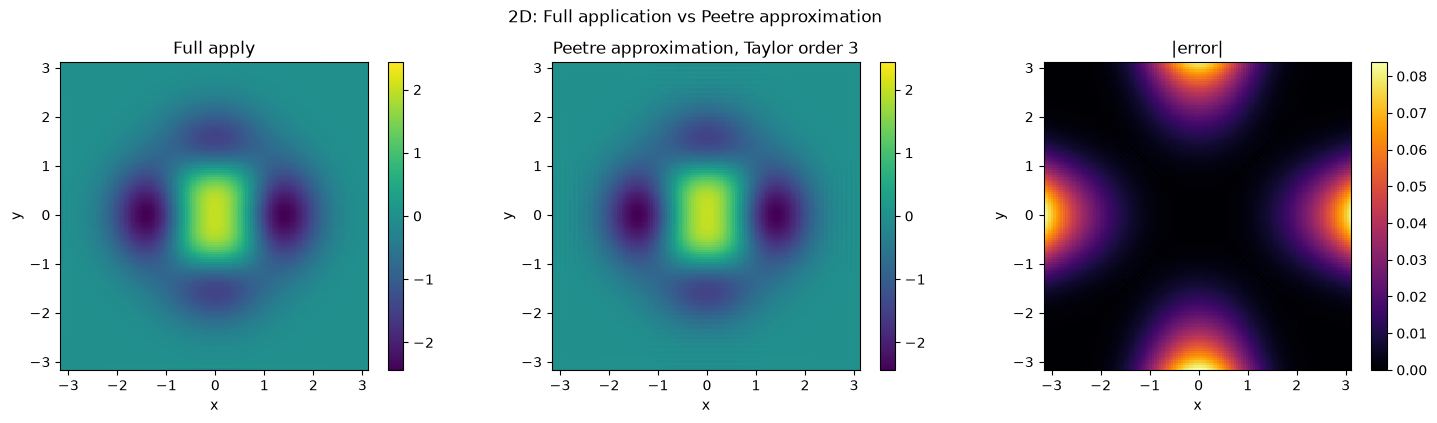

In [12]:
vmax = float(np.max(np.abs(v2_full.real)))
vmax = max(vmax, 1e-12)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

a = axes[0].pcolormesh(X2, Y2, v2_full.real, shading='auto',
                       cmap='viridis', vmin=-vmax, vmax=vmax)
axes[0].set_title('Full apply')
fig.colorbar(a, ax=axes[0], fraction=0.046)

b = axes[1].pcolormesh(X2, Y2, v2_approx.real, shading='auto',
                       cmap='viridis', vmin=-vmax, vmax=vmax)
axes[1].set_title('Peetre approximation, Taylor order 3')
fig.colorbar(b, ax=axes[1], fraction=0.046)

c = axes[2].pcolormesh(X2, Y2, np.abs(v2_full.real - v2_approx.real),
                       shading='auto', cmap='inferno')
axes[2].set_title('|error|')
fig.colorbar(c, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')

plt.suptitle('2D: Full application vs Peetre approximation')
plt.tight_layout()
plt.show()


## Timing: direct application vs approximate Peetre application

The main practical advantage of `apply_peetre` with `apply_joint=False` is speed. The local and separable parts are usually much cheaper than applying a fully joint space-frequency symbol.

The tradeoff is accuracy: the joint residual is discarded.


In [16]:
x, xi = sp.symbols('x xi', real=True)

p_time = (1 + x**2) * xi**2 # + sp.sin(x * xi)

op_time = PseudoDifferentialOperator(
    expr=p_time,
    vars_x=[x],
    mode='symbol',
)

x_grid, kx = make_1d_periodic_grid(N=512, L=2*np.pi)
u_time = np.exp(-x_grid**2)

deco_time = op_time.peetre_decomposition(
    taylor_order=2,
    taylor_x0=[0],
    asymptotic_order=None,
    refinement_sequence=('taylor',),
)

op_time.print_peetre_decomposition()

# Time full direct application.
t0 = time.perf_counter()
v_time_full = op_time.apply(
    u_time,
    x_grid,
    kx,
    boundary_condition='periodic',
    freq_window=None,
    clamp=1e12,
)
t1 = time.perf_counter()

# Time approximate Peetre application.
with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    t2 = time.perf_counter()
    v_time_approx = op_time.apply_peetre(
        u_time,
        x_grid,
        kx,
        boundary_condition='periodic',
        decomposition=deco_time,
        apply_joint=False,
        freq_window=None,
        clamp=1e12,
    )
    t3 = time.perf_counter()

print(f'Full apply time:           {t1 - t0:.4f} s')
print(f'Peetre approximation time: {t3 - t2:.4f} s')
print(f'Relative error:            {relative_error(v_time_approx, v_time_full):.3e}')


--- 1 local term(s), represented as a(x)*q(xi) ---
  (x**2 + 1) * (xi**2)
--- 0 separable non-local term(s) ---
--- 0 irreducible joint term(s) ---
local_symbol = x**2*xi**2 + xi**2
separable_symbol = 0
joint_symbol = 0
Full apply time:           0.0093 s
Peetre approximation time: 0.0019 s
Relative error:            5.137e-14


## Practical guide for `apply_peetre`

Important options:

- `decomposition`: pass a precomputed decomposition to avoid repeated symbolic work.
- `apply_joint=True`: exact Peetre application, including the joint residual.
- `apply_joint=False`: fast local-plus-separable approximation.
- `taylor_order`: controls the degree of spatial Taylor refinement of joint terms.
- `taylor_x0`: expansion point. Choose it near the region where the input field is concentrated.
- `asymptotic_order`: controls high-frequency asymptotic refinement.
- `refinement_sequence`: choose `('taylor',)`, `('asymptotic',)`, or both.
- `freq_window` and `clamp`: useful for singular or rapidly growing symbols.
- `boundary_condition`: currently supports periodic and non-periodic backends such as Dirichlet.

Recommended workflow:

1. Compute and inspect `peetre_decomposition`.
2. Verify symbol reconstruction if needed.
3. For production runs, call `apply_peetre` with a precomputed `decomposition`.
4. Use `apply_joint=False` for fast exploratory computations.
5. Use `apply_joint=True` when accuracy is more important than speed.


## Summary

The Peetre decomposition provides a structured way to split a pseudo-differential symbol into computationally useful pieces.

- The local part behaves like a variable-coefficient differential operator.
- The separable part behaves like a spatial amplitude times a Fourier multiplier.
- The joint part is the genuinely nonlocal, space-frequency coupled remainder.

`apply_peetre` exploits this structure. With `apply_joint=False`, it gives a fast approximation that is often sufficient near the Taylor expansion point or for qualitative computations. With `apply_joint=True`, it remains consistent with the full operator up to numerical and symbolic simplification errors.


In [17]:
import sympy as sp
from sympy import symbols, sin, cos, Rational, pprint

# from psiop_qwen import PseudoDifferentialOperator

# ------------------------------------------------------------------
# Spatial and frequency variables
# ------------------------------------------------------------------
x, y = symbols("x y", real=True)
xi, eta = symbols("xi eta", real=True)

# ------------------------------------------------------------------
# 2D symbols
# ------------------------------------------------------------------

# 1. Local, constant coefficients -> fast FFT path expected
sym_2d_loc_c = xi**2 + eta**2

# 2. Local, variable coefficients -> slow space-dependent path expected
sym_2d_loc_v = (
    1 + Rational(1, 2) * sin(x) * cos(y)
) * (xi**2 + eta**2)

# 3. Non-local, constant coefficients, fractional Laplacian-like symbol
# Use Rational(3, 4) instead of 0.75 for cleaner symbolic classification.
sym_2d_nloc_c = (xi**2 + eta**2)**Rational(3, 4)

# 4. Non-local, variable coefficients
sym_2d_nloc_v = (
    1 + Rational(1, 2) * sin(x) * cos(y)
) * (xi**2 + eta**2)**Rational(3, 4)

# ------------------------------------------------------------------
# Operators
# ------------------------------------------------------------------
ops_2d = {
    "2D Local (Const)": PseudoDifferentialOperator(
        sym_2d_loc_c,
        [x, y],
        mode="symbol",
    ),
    "2D Local (Var)": PseudoDifferentialOperator(
        sym_2d_loc_v,
        [x, y],
        mode="symbol",
    ),
    "2D Non-Local (Const)": PseudoDifferentialOperator(
        sym_2d_nloc_c,
        [x, y],
        mode="symbol",
    ),
    "2D Non-Local (Var)": PseudoDifferentialOperator(
        sym_2d_nloc_v,
        [x, y],
        mode="symbol",
    ),
}

# ------------------------------------------------------------------
# Peetre options
# ------------------------------------------------------------------
# These options are more verbose/refined than the bare default.
#
# For the four symbols above, there should be no irreducible joint part,
# so Taylor/asymptotic refinements are mostly shown for completeness.
# If you later test genuinely joint symbols such as sin(x*xi + y*eta),
# these options become important.
peetre_options = dict(
    taylor_order=4,
    taylor_x0=[0, 0],
    asymptotic_order=4,
    refine_joint=True,
    refinement_sequence=("taylor", "asymptotic"),
    use_cache=True,
)

# ------------------------------------------------------------------
# Helper to detect variable names robustly
# ------------------------------------------------------------------
def has_var(expr, name):
    """
    Return True if expr contains a free symbol whose name is `name`.

    This is slightly safer than expr.has(xi) if the operator internally
    recreates symbols with the same name.
    """
    return any(s.name == name for s in expr.free_symbols)

# ------------------------------------------------------------------
# Detailed Peetre decomposition loop
# ------------------------------------------------------------------
for name, op in ops_2d.items():
    print("=" * 100)
    print(f"Operator: {name}")
    print("=" * 100)

    print("\nSymbol:")
    pprint(op.symbol, use_unicode=True)

    print("\nBasic information:")
    print(f"  dim                       : {op.dim}")
    print(f"  depends on x              : {has_var(op.symbol, 'x')}")
    print(f"  depends on y              : {has_var(op.symbol, 'y')}")
    print(f"  depends on xi             : {has_var(op.symbol, 'xi')}")
    print(f"  depends on eta            : {has_var(op.symbol, 'eta')}")
    print(f"  spatially dependent       : {has_var(op.symbol, 'x') or has_var(op.symbol, 'y')}")
    print(f"  frequency dependent       : {has_var(op.symbol, 'xi') or has_var(op.symbol, 'eta')}")

    print("\n" + "-" * 100)
    print("Peetre decomposition via print_peetre_decomposition()")
    print("-" * 100)

    # Main requested method: detailed pretty-printed decomposition.
    op.print_peetre_decomposition(**peetre_options)

    # Retrieve the same decomposition dictionary for extra inspection.
    # With use_cache=True, this should reuse the cached decomposition.
    deco = op.peetre_decomposition(**peetre_options)

    print("\n" + "-" * 100)
    print("Detailed decomposition dictionary")
    print("-" * 100)

    print(f"Number of local terms       : {len(deco['local'])}")
    print(f"Number of separable terms   : {len(deco['separable'])}")
    print(f"Number of joint terms       : {len(deco['joint_residual'])}")

    print("\nLocal polynomial coefficients:")
    if deco["local"]:
        for monom, coeff in deco["local"].items():
            # In 2D, monom is usually a tuple like (2, 0), (1, 1), (0, 2), etc.
            xi_power, eta_power = monom

            monomial = 1
            if xi_power:
                monomial = monomial * xi**xi_power
            if eta_power:
                monomial = monomial * eta**eta_power

            print(f"  coefficient of xi**{xi_power} * eta**{eta_power}:")
            print(f"    monomial  = {monomial}")
            print(f"    coeff     = {coeff}")
            print(f"    term      = {sp.expand(coeff * monomial)}")
    else:
        print("  none")

    print("\nSeparable terms a(x, y) * q(xi, eta):")
    if deco["separable"]:
        for i, (a, q) in enumerate(deco["separable"], start=1):
            print(f"  separable term {i}:")
            print(f"    a(x, y)     = {a}")
            print(f"    q(xi, eta)  = {q}")
            print(f"    full term   = {sp.expand(a * q)}")
    else:
        print("  none")

    print("\nIrreducible joint residual terms:")
    if deco["joint_residual"]:
        for i, term in enumerate(deco["joint_residual"], start=1):
            print(f"  joint term {i}:")
            pprint(term, use_unicode=True)
    else:
        print("  none")

    print("\nSymbolic pieces:")
    print("local_symbol:")
    pprint(deco["local_symbol"], use_unicode=True)

    print("\nseparable_symbol:")
    pprint(deco["separable_symbol"], use_unicode=True)

    print("\njoint_symbol:")
    pprint(deco["joint_symbol"], use_unicode=True)

    # ------------------------------------------------------------------
    # Reconstruction check
    # ------------------------------------------------------------------
    reconstructed = (
        deco["local_symbol"]
        + deco["separable_symbol"]
        + deco["joint_symbol"]
    )

    reconstruction_error = sp.simplify(sp.expand(reconstructed - op.symbol))

    print("\nReconstruction check:")
    print("local_symbol + separable_symbol + joint_symbol - original_symbol =")
    pprint(reconstruction_error, use_unicode=True)

    if reconstruction_error == 0:
        print("Reconstruction is exact.")
    else:
        print("Symbolic simplification did not reduce the error to zero.")
        print("This can happen for complicated expressions, but the decomposition may still be equivalent.")

    print("\n")

Operator: 2D Local (Const)

Symbol:
 2    2
η  + ξ 

Basic information:
  dim                       : 2
  depends on x              : False
  depends on y              : False
  depends on xi             : True
  depends on eta            : True
  spatially dependent       : False
  frequency dependent       : True

----------------------------------------------------------------------------------------------------
Peetre decomposition via print_peetre_decomposition()
----------------------------------------------------------------------------------------------------
--- 1 local term(s), represented as a(x)*q(xi, eta) ---
  (1) * (eta**2 + xi**2)
--- 0 separable non-local term(s) ---
--- 0 irreducible joint term(s) ---
local_symbol = eta**2 + xi**2
separable_symbol = 0
joint_symbol = 0

----------------------------------------------------------------------------------------------------
Detailed decomposition dictionary
-------------------------------------------------------------------